### Core Concepts

1. **Threads**
A **thread** is a unique ID used to store and retrieve the state of a conversation or workflow.
A thread is essentially a **collection of checkpoints** created during multiple runs of the graph.

When invoking a graph with a checkpointer, you must provide a `thread_id`.

```python id="0c4kyu"
{"configurable": {"thread_id": "1"}}
```

The checkpointer uses this ID to save and load the conversation state.


2. **Checkpoints**
A **checkpoint** is a snapshot of the graph’s state at a specific point in time.
Multiple checkpoints together form the history of a thread.

3. **Super-steps**
A **super-step** is a single execution step of the graph where scheduled nodes run.

Example:

```text id="0r5dhj"
START → A → B → END
```

    After each super-step, a checkpoint is created, allowing the graph state to be saved and restored.


### Persistence

LangGraph includes a built-in persistence layer using checkpointers.

#### How Checkpointers Work
When a graph is compiled with a checkpointer, the checkpointer automatically saves a snapshot (checkpoint) of the graph state after every super-step (a complete cycle or step in the graph execution).

#### Capabilities Enabled
These checkpoints are saved to a thread that remains accessible after the graph execution finishes. Because the graph's state can be accessed post-execution, this persistence layer enables several powerful features:

   - Memory: Provides the graph with the ability to recall past states and interactions.

   - Human-in-the-Loop: Allows a human to inspect or intervene in the execution process.
    
   - Time Travel: Makes it possible to rewind the graph state to a previous point.
    
   - Fault-Tolerance: Enables the system to recover from failures by resuming execution from the last saved checkpoint.


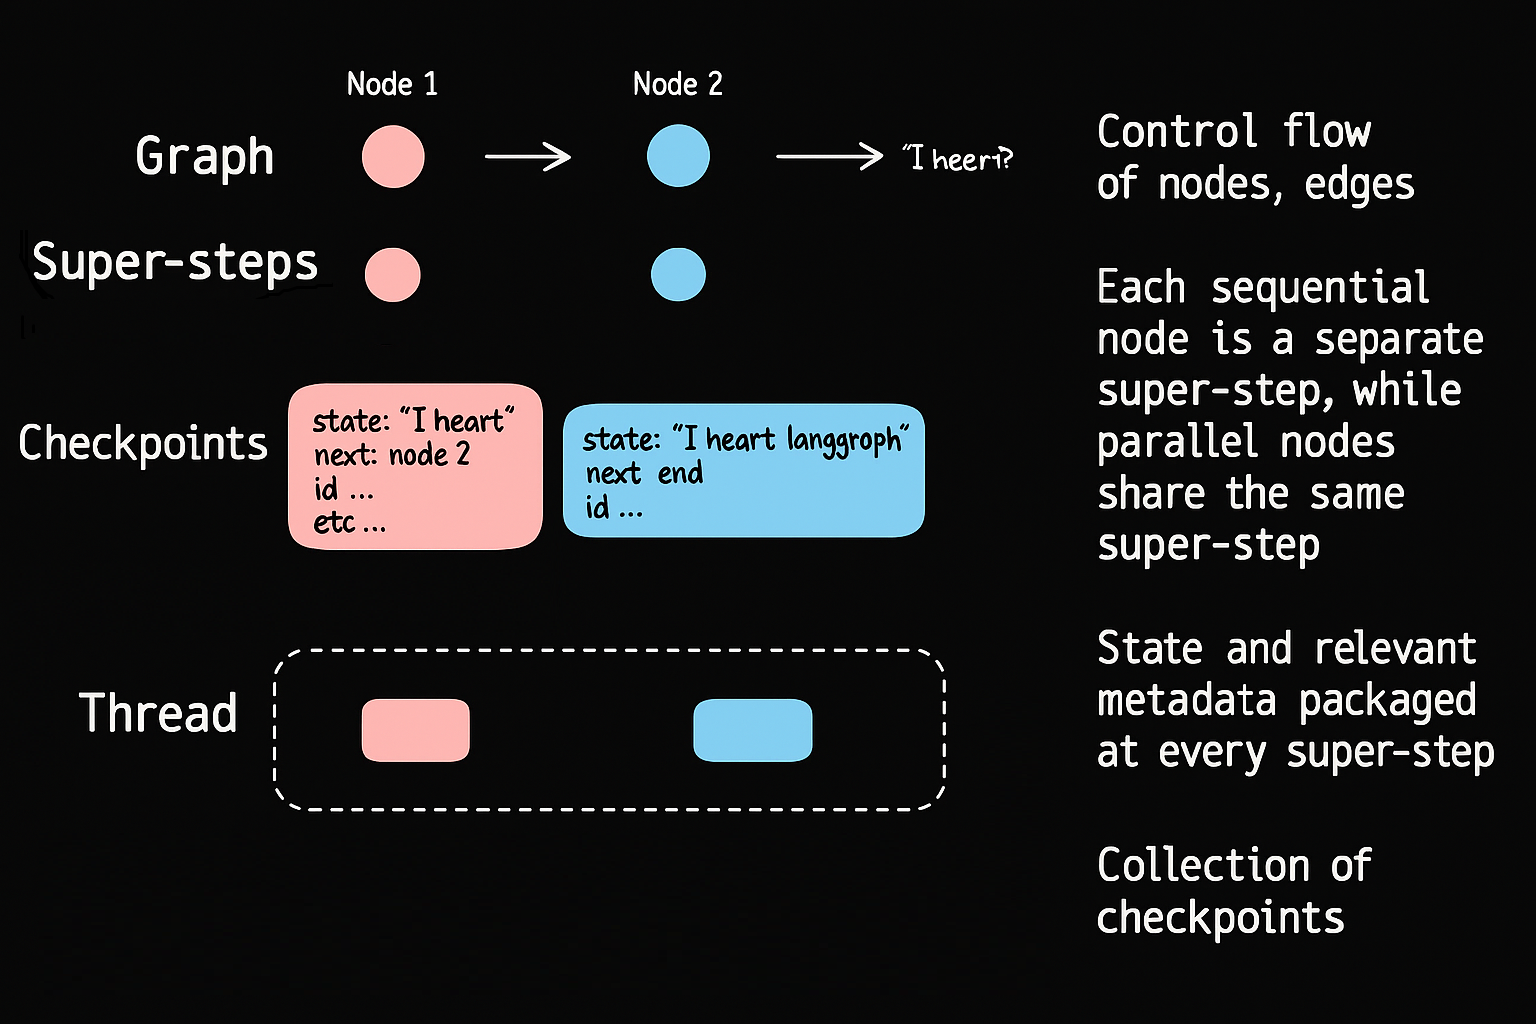

## Example 1 : Persistance with InMemorySaver

/home/labuser/.local/lib/python3.10/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


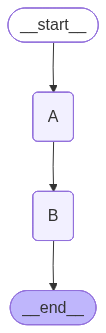

In [1]:
from typing import TypedDict, Optional
from langgraph.graph import StateGraph
from langgraph.checkpoint.memory import InMemorySaver
 
#  Define the state schema ---

#The total=False argument in the class definition is a feature that 
#allows the fields of the TypedDict to be optional.

class AgentState(TypedDict, total=False):
    a: Optional[str]  #Annotated[Optional[str],operator.add]
    b: Optional[str]
 
#  Define nodes ---
def node_a(state: AgentState) -> AgentState:
    state["a"] = "Hello"
    return state
 
def node_b(state: AgentState) -> AgentState:
    state["b"] = state["a"] + " World!"
    return state
 
# Build graph ---
builder = StateGraph(AgentState)
 
builder.add_node("A", node_a)
builder.add_node("B", node_b)
 
builder.set_entry_point("A")
builder.add_edge("A", "B")
 
#  Compile with a checkpoint saver ---
graph = builder.compile(checkpointer=InMemorySaver())
graph



In [2]:
config = {"configurable": {"thread_id": "thread_1"}}

final_state = graph.invoke({"a":"Hi"}, config=config)
print(final_state)

{'a': 'Hello', 'b': 'Hello World!'}


In [3]:
# Assuming you have a configured graph object `graph` and a configuration `config`
from rich import print
# Get the state history based on the config
state_history = graph.get_state_history(config)

# Print or inspect the state history
print(state_history)

from rich import print
#  iterate through the states
for i, state in enumerate(state_history):
    print(f"State {i + 1}: {state}")


<generator object Pregel.get_state_history at 0x750d90e4fbc0>

State 1: StateSnapshot(values={'a': 'Hello', 'b': 'Hello World!'}, next=(), config={'configurable': {'thread_id': 
'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f14de39-480c-6638-8002-d510d7efe294'}}, metadata={'source': 
'loop', 'step': 2, 'parents': {}}, created_at='2026-05-12T09:18:46.957819+00:00', parent_config={'configurable': 
{'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f14de39-480a-6985-8001-7a508f8a67a5'}}, tasks=(),
interrupts=())

State 2: StateSnapshot(values={'a': 'Hello'}, next=('B',), config={'configurable': {'thread_id': 'thread_1', 
'checkpoint_ns': '', 'checkpoint_id': '1f14de39-480a-6985-8001-7a508f8a67a5'}}, metadata={'source': 'loop', 'step':
1, 'parents': {}}, created_at='2026-05-12T09:18:46.957084+00:00', parent_config={'configurable': {'thread_id': 
'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f14de39-4807-6b67-8000-73c1c8c57caf'}}, 
tasks=(PregelTask(id='bae6c166-36d5-f198-8256-f1b1011c9da9', name='B', path=('__pregel_pull', 'B'), error=None, 
interrupts=(), state=None, result={'a': 'Hello', 'b': 'Hello World!'}),), interrupts=())

State 3: StateSnapshot(values={'a': 'Hi'}, next=('A',), config={'configurable': {'thread_id': 'thread_1', 
'checkpoint_ns': '', 'checkpoint_id': '1f14de39-4807-6b67-8000-73c1c8c57caf'}}, metadata={'source': 'loop', 'step':
0, 'parents': {}}, created_at='2026-05-12T09:18:46.955901+00:00', parent_config={'configurable': {'thread_id': 
'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f14de39-4805-65c5-bfff-ddb5aed5332f'}}, 
tasks=(PregelTask(id='7056dcf2-ee2d-0d41-6365-3b366568044a', name='A', path=('__pregel_pull', 'A'), error=None, 
interrupts=(), state=None, result={'a': 'Hello'}),), interrupts=())

State 4: StateSnapshot(values={}, next=('__start__',), config={'configurable': {'thread_id': 'thread_1', 
'checkpoint_ns': '', 'checkpoint_id': '1f14de39-4805-65c5-bfff-ddb5aed5332f'}}, metadata={'source': 'input', 
'step': -1, 'parents': {}}, created_at='2026-05-12T09:18:46.954941+00:00', parent_config=None, 
tasks=(PregelTask(id='2c837d3a-ab0b-7907-972f-844b61d80154', name='__start__', path=('__pregel_pull', '__start__'),
error=None, interrupts=(), state=None, result={'a': 'Hi'}),), interrupts=())

In [4]:
config = {"configurable": {"thread_id": "thread_1"}}

final_state = graph.invoke({"a":"I am Raj"}, config=config)

print(final_state)

{'a': 'Hello', 'b': 'Hello World!'}

In [5]:
# Assuming you have a configured graph object `graph` and a configuration `config`

# Get the state history based on the config
state_history = graph.get_state_history(config)

# Print or inspect the state history
print(state_history)

from rich import print
#  iterate through the states
for i, state in enumerate(state_history):
    print(f"State {i + 1}: {state}")

<generator object Pregel.get_state_history at 0x750d904a8120>

State 1: StateSnapshot(values={'a': 'Hello', 'b': 'Hello World!'}, next=(), config={'configurable': {'thread_id': 
'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f14de39-9319-63e0-8006-cd0db5f3f5bb'}}, metadata={'source': 
'loop', 'step': 6, 'parents': {}}, created_at='2026-05-12T09:18:54.827404+00:00', parent_config={'configurable': 
{'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f14de39-9317-6bd8-8005-b67761c81d71'}}, tasks=(),
interrupts=())

State 2: StateSnapshot(values={'a': 'Hello', 'b': 'Hello World!'}, next=('B',), config={'configurable': 
{'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f14de39-9317-6bd8-8005-b67761c81d71'}}, 
metadata={'source': 'loop', 'step': 5, 'parents': {}}, created_at='2026-05-12T09:18:54.826789+00:00', 
parent_config={'configurable': {'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': 
'1f14de39-9314-6fd9-8004-5ab47f23e329'}}, tasks=(PregelTask(id='3fdad719-8118-bb01-934d-1389119c3d87', name='B', 
path=('__pregel_pull', 'B'), error=None, interrupts=(), state=None, result={'a': 'Hello', 'b': 'Hello World!'}),), 
interrupts=())

State 3: StateSnapshot(values={'a': 'I am Raj', 'b': 'Hello World!'}, next=('A',), config={'configurable': 
{'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f14de39-9314-6fd9-8004-5ab47f23e329'}}, 
metadata={'source': 'loop', 'step': 4, 'parents': {}}, created_at='2026-05-12T09:18:54.825659+00:00', 
parent_config={'configurable': {'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': 
'1f14de39-9312-6bfd-8003-2fe9e848b45f'}}, tasks=(PregelTask(id='9064b1e3-eed9-d7a0-cb0e-0921007f7374', name='A', 
path=('__pregel_pull', 'A'), error=None, interrupts=(), state=None, result={'a': 'Hello', 'b': 'Hello World!'}),), 
interrupts=())

State 4: StateSnapshot(values={'a': 'Hello', 'b': 'Hello World!'}, next=('__start__',), config={'configurable': 
{'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f14de39-9312-6bfd-8003-2fe9e848b45f'}}, 
metadata={'source': 'input', 'step': 3, 'parents': {}}, created_at='2026-05-12T09:18:54.824742+00:00', 
parent_config={'configurable': {'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': 
'1f14de39-480c-6638-8002-d510d7efe294'}}, tasks=(PregelTask(id='45ca77e2-6590-9035-4296-623f8ec471ad', 
name='__start__', path=('__pregel_pull', '__start__'), error=None, interrupts=(), state=None, result={'a': 'I am 
Raj'}),), interrupts=())

State 5: StateSnapshot(values={'a': 'Hello', 'b': 'Hello World!'}, next=(), config={'configurable': {'thread_id': 
'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f14de39-480c-6638-8002-d510d7efe294'}}, metadata={'source': 
'loop', 'step': 2, 'parents': {}}, created_at='2026-05-12T09:18:46.957819+00:00', parent_config={'configurable': 
{'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f14de39-480a-6985-8001-7a508f8a67a5'}}, tasks=(),
interrupts=())

State 6: StateSnapshot(values={'a': 'Hello'}, next=('B',), config={'configurable': {'thread_id': 'thread_1', 
'checkpoint_ns': '', 'checkpoint_id': '1f14de39-480a-6985-8001-7a508f8a67a5'}}, metadata={'source': 'loop', 'step':
1, 'parents': {}}, created_at='2026-05-12T09:18:46.957084+00:00', parent_config={'configurable': {'thread_id': 
'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f14de39-4807-6b67-8000-73c1c8c57caf'}}, 
tasks=(PregelTask(id='bae6c166-36d5-f198-8256-f1b1011c9da9', name='B', path=('__pregel_pull', 'B'), error=None, 
interrupts=(), state=None, result={'a': 'Hello', 'b': 'Hello World!'}),), interrupts=())

State 7: StateSnapshot(values={'a': 'Hi'}, next=('A',), config={'configurable': {'thread_id': 'thread_1', 
'checkpoint_ns': '', 'checkpoint_id': '1f14de39-4807-6b67-8000-73c1c8c57caf'}}, metadata={'source': 'loop', 'step':
0, 'parents': {}}, created_at='2026-05-12T09:18:46.955901+00:00', parent_config={'configurable': {'thread_id': 
'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f14de39-4805-65c5-bfff-ddb5aed5332f'}}, 
tasks=(PregelTask(id='7056dcf2-ee2d-0d41-6365-3b366568044a', name='A', path=('__pregel_pull', 'A'), error=None, 
interrupts=(), state=None, result={'a': 'Hello'}),), interrupts=())

State 8: StateSnapshot(values={}, next=('__start__',), config={'configurable': {'thread_id': 'thread_1', 
'checkpoint_ns': '', 'checkpoint_id': '1f14de39-4805-65c5-bfff-ddb5aed5332f'}}, metadata={'source': 'input', 
'step': -1, 'parents': {}}, created_at='2026-05-12T09:18:46.954941+00:00', parent_config=None, 
tasks=(PregelTask(id='2c837d3a-ab0b-7907-972f-844b61d80154', name='__start__', path=('__pregel_pull', '__start__'),
error=None, interrupts=(), state=None, result={'a': 'Hi'}),), interrupts=())

In [8]:
config = {"configurable": {"thread_id": "thread_2"}}

final_state = graph.invoke({"a":"I am Raj"}, config=config)

print(final_state)

{'a': 'Hello', 'b': 'Hello World!'}

In [6]:
# Assuming you have a configured graph object `graph` and a configuration `config`

# Get the state history based on the config
state_history = graph.get_state_history(config)

# Print or inspect the state history
print(state_history)

from rich import print
#  iterate through the states
for i, state in enumerate(state_history):
    print(f"State {i + 1}: {state}")

<generator object Pregel.get_state_history at 0x750d904a8430>

State 1: StateSnapshot(values={'a': 'Hello', 'b': 'Hello World!'}, next=(), config={'configurable': {'thread_id': 
'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f14de39-9319-63e0-8006-cd0db5f3f5bb'}}, metadata={'source': 
'loop', 'step': 6, 'parents': {}}, created_at='2026-05-12T09:18:54.827404+00:00', parent_config={'configurable': 
{'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f14de39-9317-6bd8-8005-b67761c81d71'}}, tasks=(),
interrupts=())

State 2: StateSnapshot(values={'a': 'Hello', 'b': 'Hello World!'}, next=('B',), config={'configurable': 
{'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f14de39-9317-6bd8-8005-b67761c81d71'}}, 
metadata={'source': 'loop', 'step': 5, 'parents': {}}, created_at='2026-05-12T09:18:54.826789+00:00', 
parent_config={'configurable': {'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': 
'1f14de39-9314-6fd9-8004-5ab47f23e329'}}, tasks=(PregelTask(id='3fdad719-8118-bb01-934d-1389119c3d87', name='B', 
path=('__pregel_pull', 'B'), error=None, interrupts=(), state=None, result={'a': 'Hello', 'b': 'Hello World!'}),), 
interrupts=())

State 3: StateSnapshot(values={'a': 'I am Raj', 'b': 'Hello World!'}, next=('A',), config={'configurable': 
{'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f14de39-9314-6fd9-8004-5ab47f23e329'}}, 
metadata={'source': 'loop', 'step': 4, 'parents': {}}, created_at='2026-05-12T09:18:54.825659+00:00', 
parent_config={'configurable': {'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': 
'1f14de39-9312-6bfd-8003-2fe9e848b45f'}}, tasks=(PregelTask(id='9064b1e3-eed9-d7a0-cb0e-0921007f7374', name='A', 
path=('__pregel_pull', 'A'), error=None, interrupts=(), state=None, result={'a': 'Hello', 'b': 'Hello World!'}),), 
interrupts=())

State 4: StateSnapshot(values={'a': 'Hello', 'b': 'Hello World!'}, next=('__start__',), config={'configurable': 
{'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f14de39-9312-6bfd-8003-2fe9e848b45f'}}, 
metadata={'source': 'input', 'step': 3, 'parents': {}}, created_at='2026-05-12T09:18:54.824742+00:00', 
parent_config={'configurable': {'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': 
'1f14de39-480c-6638-8002-d510d7efe294'}}, tasks=(PregelTask(id='45ca77e2-6590-9035-4296-623f8ec471ad', 
name='__start__', path=('__pregel_pull', '__start__'), error=None, interrupts=(), state=None, result={'a': 'I am 
Raj'}),), interrupts=())

State 5: StateSnapshot(values={'a': 'Hello', 'b': 'Hello World!'}, next=(), config={'configurable': {'thread_id': 
'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f14de39-480c-6638-8002-d510d7efe294'}}, metadata={'source': 
'loop', 'step': 2, 'parents': {}}, created_at='2026-05-12T09:18:46.957819+00:00', parent_config={'configurable': 
{'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f14de39-480a-6985-8001-7a508f8a67a5'}}, tasks=(),
interrupts=())

State 6: StateSnapshot(values={'a': 'Hello'}, next=('B',), config={'configurable': {'thread_id': 'thread_1', 
'checkpoint_ns': '', 'checkpoint_id': '1f14de39-480a-6985-8001-7a508f8a67a5'}}, metadata={'source': 'loop', 'step':
1, 'parents': {}}, created_at='2026-05-12T09:18:46.957084+00:00', parent_config={'configurable': {'thread_id': 
'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f14de39-4807-6b67-8000-73c1c8c57caf'}}, 
tasks=(PregelTask(id='bae6c166-36d5-f198-8256-f1b1011c9da9', name='B', path=('__pregel_pull', 'B'), error=None, 
interrupts=(), state=None, result={'a': 'Hello', 'b': 'Hello World!'}),), interrupts=())

State 7: StateSnapshot(values={'a': 'Hi'}, next=('A',), config={'configurable': {'thread_id': 'thread_1', 
'checkpoint_ns': '', 'checkpoint_id': '1f14de39-4807-6b67-8000-73c1c8c57caf'}}, metadata={'source': 'loop', 'step':
0, 'parents': {}}, created_at='2026-05-12T09:18:46.955901+00:00', parent_config={'configurable': {'thread_id': 
'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f14de39-4805-65c5-bfff-ddb5aed5332f'}}, 
tasks=(PregelTask(id='7056dcf2-ee2d-0d41-6365-3b366568044a', name='A', path=('__pregel_pull', 'A'), error=None, 
interrupts=(), state=None, result={'a': 'Hello'}),), interrupts=())

State 8: StateSnapshot(values={}, next=('__start__',), config={'configurable': {'thread_id': 'thread_1', 
'checkpoint_ns': '', 'checkpoint_id': '1f14de39-4805-65c5-bfff-ddb5aed5332f'}}, metadata={'source': 'input', 
'step': -1, 'parents': {}}, created_at='2026-05-12T09:18:46.954941+00:00', parent_config=None, 
tasks=(PregelTask(id='2c837d3a-ab0b-7907-972f-844b61d80154', name='__start__', path=('__pregel_pull', '__start__'),
error=None, interrupts=(), state=None, result={'a': 'Hi'}),), interrupts=())